In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing.csv")

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [6]:
colums_name = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

In [7]:
for i,col in enumerate(colums_name):
    row = i // 3
    col_index = i % 3
    print(row,col_index)
    

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1
2 2


In [8]:
data.corr(numeric_only=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


<Axes: >

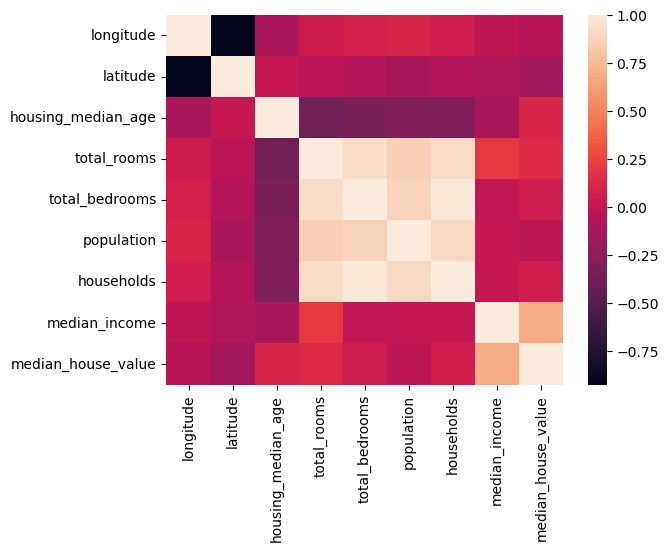

In [9]:
sns.heatmap(data.corr(numeric_only=True))

In [10]:
# find outliers

In [11]:
def find_outliers(data,thres_hold=1.5):
    numeric_colums = data.select_dtypes(include=["float64","int64"]).columns
    outlier_summary = {}
    for col in numeric_colums:
        Q1 =data[col].quantile(0.25)
        Q3 =data[col].quantile(0.75)
        IQR = Q3-Q1
        lower_bound = Q1 - thres_hold* IQR
        upper_bound = Q3 + thres_hold* IQR
        outliers = data[(data[col] <lower_bound) | (data[col] > upper_bound)]
        outlier_summary[col] = {
            "outlier_counts" : outliers.shape[0],
            "outlier_percantage" : 100 * outliers.shape[0] / data.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound": upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [12]:
find_outliers(data,1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outlier_counts,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outlier_percantage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [13]:
def remove_targerts_col(data,targets_col,thres_hold=1.5) :
    Q1 =data[col].quantile(0.25)
    Q3 =data[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - thres_hold* IQR
    upper_bound = Q3 + thres_hold* IQR
    return  data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

In [14]:
print("original data shape", data.shape )

original data shape (20640, 10)


In [15]:
print(f"remove_targets_col {(remove_targerts_col(data,"median_house_value")).shape}")

remove_targets_col (19569, 10)


In [16]:
data.shape

(20640, 10)

In [17]:
def remove_all_clean(data,thres_hold=1.5):
    numeric_colums = data.select_dtypes(include=["float64","int64"]).columns
    data_clean = data.copy()
    for col in numeric_colums:
        Q1 =data[col].quantile(0.25)
        Q3 =data[col].quantile(0.75)
        IQR = Q3-Q1
        lower_bound = Q1 - thres_hold* IQR
        upper_bound = Q3 + thres_hold* IQR
        data_clean = data_clean[(data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)]
    return data_clean.copy()

In [18]:
data_clean = remove_all_clean(data)

In [19]:
data_clean.shape

(17446, 10)

In [20]:
data = remove_targerts_col(data,"median_house_value")

In [21]:
data.shape

(19569, 10)

In [22]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [23]:
data["total_bedrooms"].unique()

array([ 129., 1106.,  190., ..., 3008., 1857., 1052.], shape=(1905,))

In [24]:
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

In [25]:
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [26]:
data = pd.get_dummies(data,columns=["ocean_proximity"],drop_first=True)

In [27]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [28]:
X = data.drop("median_house_value",axis=1)
y = data["median_house_value"]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [31]:
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor,GradientBoostingRegressor

In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [33]:
def model_score (true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    r2 = r2_score(true,predicted)
    return mae,mse,r2

In [34]:
models = {
    "Linear Regressor ": LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "KNeighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "xgboost" : XGBRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Ada Boost" : AdaBoostRegressor(),
    "Gradian Regressor" : GradientBoostingRegressor()


}

In [36]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_mse, model_train_r2 = model_score(y_train,y_train_pred)
    model_test_mae, model_test_mse, model_test_r2 = model_score(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("model performance for traning Set")
    print("Root Mean Squared Error : ",model_train_mse)
    print("Mean absolute Squared Error : ",model_train_mae)
    print("R2 Score : ",model_train_r2)
    print("<---------------------------------------->")
    print(list(models.keys())[i])
    print("model performance for test Set")
    print("Root Mean Squared Error : ",model_test_mse)
    print("Mean absolute Squared Error : ",model_test_mae)
    print("R2 Score : ",model_test_r2)
    print("<---------------------------------------->")
    print("\n")
    


Linear Regressor 
model performance for traning Set
Root Mean Squared Error :  3532846359.5543957
Mean absolute Squared Error :  43924.89591411993
R2 Score :  0.6113556571551536
<---------------------------------------->
Linear Regressor 
model performance for test Set
Root Mean Squared Error :  3425738991.1174803
Mean absolute Squared Error :  43310.20391112389
R2 Score :  0.6260560567074169
<---------------------------------------->


Lasso
model performance for traning Set
Root Mean Squared Error :  3532849327.693715
Mean absolute Squared Error :  43925.44014908859
R2 Score :  0.6113553306335793
<---------------------------------------->
Lasso
model performance for test Set
Root Mean Squared Error :  3425747400.73713
Mean absolute Squared Error :  43310.44245392172
R2 Score :  0.6260551387372091
<---------------------------------------->


Ridge
model performance for traning Set
Root Mean Squared Error :  3533115065.4150906
Mean absolute Squared Error :  43929.78475781256
R2 Score :

In [37]:
param = {
    "n_estimators" :[50,100,150,250,300,400],
    "learning_rate":[0.01,0.1],
    "max_depth":[5,8,12,25,32,40],
    "colsample_bytree" : [0.3,0.4,0.6,0.8,1]
}

In [38]:
from sklearn.model_selection import RandomizedSearchCV



In [39]:
rsv = RandomizedSearchCV(estimator=XGBRegressor(),param_distributions=param,cv=5,n_jobs=-1)

In [40]:
rsv.fit(X_train,y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.3, 0.4, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [5, 8, ...], 'n_estimators': [50, 100, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [41]:
rsv.best_params_

{'n_estimators': 400,
 'max_depth': 40,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [53]:
model = XGBRegressor(n_estimators=400,max_depth=25,learning_rate=0.01,colsample_bytree=0.8)

In [54]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [55]:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_mse, model_train_r2 = model_score(y_train,y_train_pred)
    model_test_mae, model_test_mse, model_test_r2 = model_score(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("model performance for traning Set")
    print("Root Mean Squared Error : ",model_train_mse)
    print("Mean absolute Squared Error : ",model_train_mae)
    print("R2 Score : ",model_train_r2)
    print("<---------------------------------------->")
    print(list(models.keys())[i])
    print("model performance for test Set")
    print("Root Mean Squared Error : ",model_test_mse)
    print("Mean absolute Squared Error : ",model_test_mae)
    print("R2 Score : ",model_test_r2)
    print("<---------------------------------------->")
    print("\n")
    


Gradian Regressor
model performance for traning Set
Root Mean Squared Error :  25431791.71569384
Mean absolute Squared Error :  2983.370961731739
R2 Score :  0.9972022780011414
<---------------------------------------->
Gradian Regressor
model performance for test Set
Root Mean Squared Error :  1785661516.9111822
Mean absolute Squared Error :  28934.20792618281
R2 Score :  0.8050822579446526
<---------------------------------------->




In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
grid = GridSearchCV(estimator=XGBRegressor(),param_grid=param,cv=5,n_jobs=-1,verbose=2)

In [58]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.3, 0.4, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [5, 8, ...], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [59]:
grid.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 400}

In [60]:
grid.best_score_


np.float64(0.8061846636381971)

In [61]:
xgboost_model = XGBRegressor(colsample_bytree=1,max_depth=5,n_estimators=400,learning_rate=0.1)

In [62]:
xgboost_model.fit(X_train,y_train)
y_pred = xgboost_model.predict(X_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

28180.38080548743
1683546753.7804003
0.8162288156049187
